### Customer Segmentation Project

   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Genre                   200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB
None


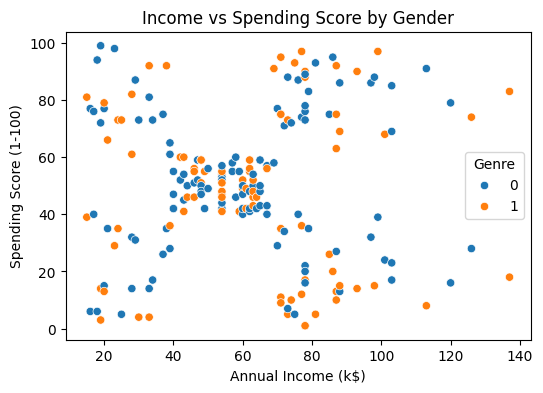

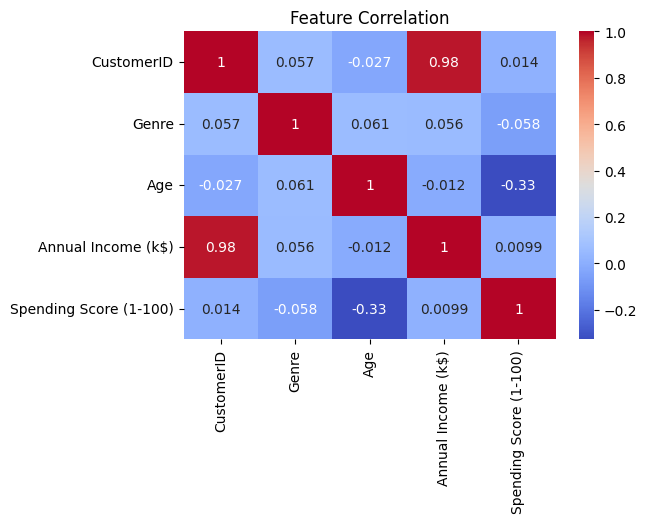

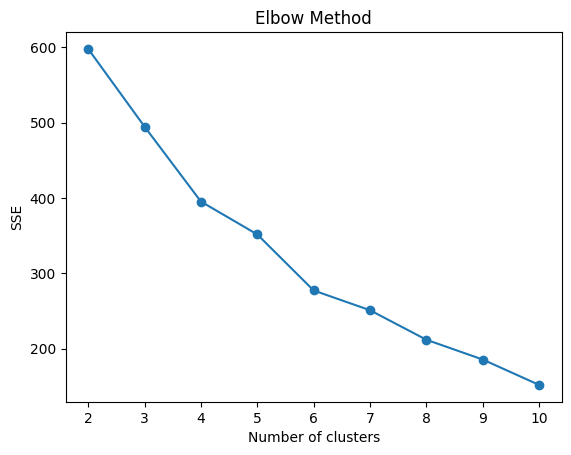

Silhouette Score: 0.2719102346618833


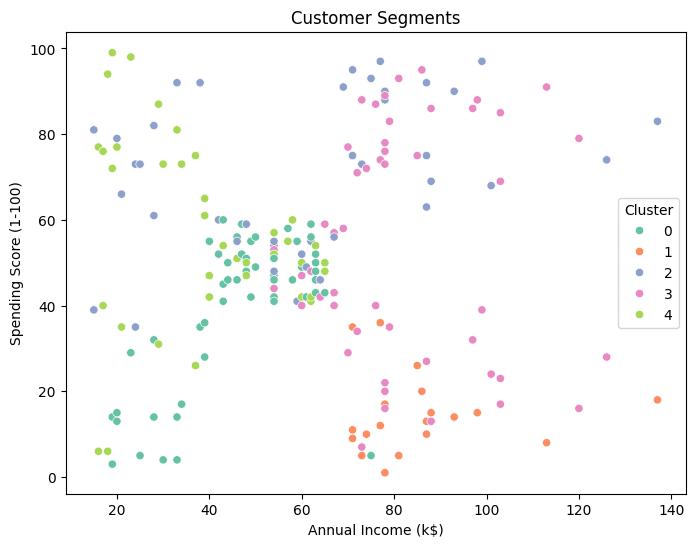

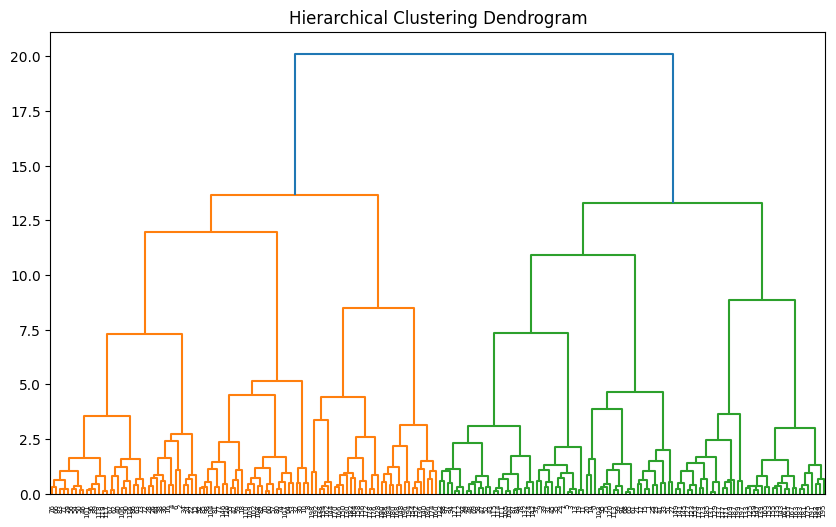


Cluster 2 Summary:
       CustomerID  Genre        Age  Annual Income (k$)  \
count   42.000000   42.0  42.000000           42.000000   
mean   100.809524    1.0  28.690476           60.904762   
std     61.330865    0.0   7.110583           29.017917   
min      1.000000    1.0  18.000000           15.000000   
25%     44.500000    1.0  22.500000           39.000000   
50%    102.000000    1.0  28.500000           61.500000   
75%    149.000000    1.0  34.750000           77.750000   
max    200.000000    1.0  40.000000          137.000000   

       Spending Score (1-100)  Cluster  
count               42.000000     42.0  
mean                70.238095      2.0  
std                 17.621785      0.0  
min                 35.000000      2.0  
25%                 55.250000      2.0  
50%                 73.000000      2.0  
75%                 86.750000      2.0  
max                 97.000000      2.0  

Cluster 4 Summary:
       CustomerID  Genre        Age  Annual Income (k$)  \


In [6]:
# -------------------------------
# 1. Import Libraries
# -------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

# -------------------------------
# 2. Load Dataset
# -------------------------------
# Example: Kaggle Mall Customer Segmentation dataset
df = pd.read_csv("Documents/UnsuperVised Machine Learning/Mall_Customers.csv")

# Quick look
print(df.head())
print(df.info())

# -------------------------------
# 3. Data Preprocessing
# -------------------------------
# Encode categorical variable (Gender)
le = LabelEncoder()
df['Genre'] = le.fit_transform(df['Genre'])

# Select features
X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Genre']]

# Normalize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -------------------------------
# 4. Exploratory Data Analysis
# -------------------------------
plt.figure(figsize=(6,4))
sns.scatterplot(x=df['Annual Income (k$)'], y=df['Spending Score (1-100)'], hue=df['Genre'])
plt.title("Income vs Spending Score by Gender")
plt.show()

# Correlation heatmap
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

# -------------------------------
# 5. K-Means Clustering
# -------------------------------
# Elbow Method
sse = []
for k in range(2,11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    sse.append(kmeans.inertia_)

plt.plot(range(2,11), sse, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of clusters")
plt.ylabel("SSE")
plt.show()

# Fit optimal K (say 5)
kmeans = KMeans(n_clusters=5, random_state=42)
labels = kmeans.fit_predict(X_scaled)
df['Cluster'] = labels

# Silhouette Score
print("Silhouette Score:", silhouette_score(X_scaled, labels))

# -------------------------------
# 6. Visualize Clusters
# -------------------------------
plt.figure(figsize=(8,6))
sns.scatterplot(x=df['Annual Income (k$)'], y=df['Spending Score (1-100)'], hue=df['Cluster'], palette="Set2")
plt.title("Customer Segments")
plt.show()

# -------------------------------
# 7. Hierarchical Clustering (Validation)
# -------------------------------
linked = linkage(X_scaled, 'ward')
plt.figure(figsize=(10,6))
dendrogram(linked, orientation='top', distance_sort='descending', show_leaf_counts=False)
plt.title("Hierarchical Clustering Dendrogram")
plt.show()

# -------------------------------
# 8. Business Insights
# -------------------------------
for cluster in df['Cluster'].unique():
    segment = df[df['Cluster'] == cluster]
    print(f"\nCluster {cluster} Summary:")
    print(segment.describe())
